# Private TT-LoRA Enron Analysis

This notebook analyzes the private TT-LoRA Enron experiments across:
- rank: `2`, `6`, `10`
- epsilon: `0.5`, `3.0`, `8.0`, `20.0`
- variable core counts chosen from the lowest-parameter configuration for each core count

Main questions:
1. Does core count matter in private training?
2. How does TT-LoRA rank matter?
3. Do lower epsilon values visibly harm convergence for the same setting?
4. Which settings are stable versus unstable based on the trend lines?

We start from a single step-level combined CSV and then build a run-level summary table for comparisons.


In [21]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')

phase_root = Path('/home/pkunwar/characterize_ttlora/phases/2.2.different_dataset_models_rank')
runs_dir = phase_root / 'runs'
analysis_outputs = phase_root / 'analysis_outputs'
analysis_outputs.mkdir(parents=True, exist_ok=True)

combined_csv_path = analysis_outputs / 'private_ttlora_enron_all_steps.csv'
run_summary_csv_path = analysis_outputs / 'private_ttlora_enron_run_summary.csv'
plots_dir = analysis_outputs / 'plots'
plots_dir.mkdir(parents=True, exist_ok=True)

combined_csv_path


PosixPath('/home/pkunwar/characterize_ttlora/phases/2.2.different_dataset_models_rank/analysis_outputs/private_ttlora_enron_all_steps.csv')

## Load Combined CSV

If the combined CSV does not exist yet, run the combiner script first:

```bash
python phases/2.2.different_dataset_models_rank/scripts/combine_private_ttlora_results.py \
  --runs-dir phases/2.2.different_dataset_models_rank/runs \
  --output-csv phases/2.2.different_dataset_models_rank/analysis_outputs/private_ttlora_enron_all_steps.csv
```


In [22]:
df = pd.read_csv(combined_csv_path)

numeric_cols = [
    'record_index', 'rank', 'epsilon', 'core_count', 'lr', 'effective_bs', 'epoch', 'step',
    'eps_rdp', 'alpha_rdp', 'snr', 'signal', 'noise', 'noise_limit',
    'train.perplexity', 'eval.perplexity', 'val.perplexity',
    'train.eval_losses', 'eval.eval_losses', 'val.eval_losses',
    'num_params', 'num_non_embedding_params', 'total_flos',
    'train.entropy_losses', 'train.tok_logprobs', 'train.lin_logprobs',
    'eval.entropy_losses', 'eval.tok_logprobs', 'eval.lin_logprobs',
    'val.entropy_losses', 'val.tok_logprobs', 'val.lin_logprobs',
    'eps_low', 'eps_estimate', 'eps_upper', 'med_clip', 'max_clip', 'min_clip',
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['is_private'] = df['epsilon'].notna()
df['epsilon_label'] = df['epsilon'].map(lambda x: f'{x:g}' if pd.notna(x) else 'unknown')
df['setting_id'] = (
    df['dataset'].astype(str)
    + '|rank=' + df['rank'].astype('Int64').astype(str)
    + '|core=' + df['core_count'].astype('Int64').astype(str)
    + '|eps=' + df['epsilon_label']
)

print('rows:', len(df))
print('unique runs:', df['run_name'].nunique())
display(df.head())


rows: 2376
unique runs: 216


,run_name,run_dir,record_index,peft,nonprivate,dataset,rank,epsilon,core_count,lr,...,max_clip,min_clip,source_csv,source_file,epsilon_from_file,combined_row_index,row_index_within_file,is_private,epsilon_label,setting_id
0,ttlora_nonprivate_no_datasetenron_rank10_eps0....,/usr/projects/unsupgan/pkunwar/ttlora-dp/runs/...,0,ttlora,no,enron,10,0.5,10,0.002,...,NaN,NaN,/home/pkunwar/characterize_ttlora/phases/2.2.d...,rank2_6_10_0.5eps.csv,0.5,0,0,True,0.5,enron|rank=10|core=10|eps=0.5
1,ttlora_nonprivate_no_datasetenron_rank10_eps0....,/usr/projects/unsupgan/pkunwar/ttlora-dp/runs/...,1,ttlora,no,enron,10,0.5,10,0.002,...,NaN,NaN,/home/pkunwar/characterize_ttlora/phases/2.2.d...,rank2_6_10_0.5eps.csv,0.5,1,1,True,0.5,enron|rank=10|core=10|eps=0.5
2,ttlora_nonprivate_no_datasetenron_rank10_eps0....,/usr/projects/unsupgan/pkunwar/ttlora-dp/runs/...,2,ttlora,no,enron,10,0.5,10,0.002,...,NaN,NaN,/home/pkunwar/characterize_ttlora/phases/2.2.d...,rank2_6_10_0.5eps.csv,0.5,2,2,True,0.5,enron|rank=10|core=10|eps=0.5
3,ttlora_nonprivate_no_datasetenron_rank10_eps0....,/usr/projects/unsupgan/pkunwar/ttlora-dp/runs/...,3,ttlora,no,enron,10,0.5,10,0.002,...,NaN,NaN,/home/pkunwar/characterize_ttlora/phases/2.2.d...,rank2_6_10_0.5eps.csv,0.5,3,3,True,0.5,enron|rank=10|core=10|eps=0.5
4,ttlora_nonprivate_no_datasetenron_rank10_eps0....,/usr/projects/unsupgan/pkunwar/ttlora-dp/runs/...,4,ttlora,no,enron,10,0.5,10,0.002,...,NaN,NaN,/home/pkunwar/characterize_ttlora/phases/2.2.d...,rank2_6_10_0.5eps.csv,0.5,4,4,True,0.5,enron|rank=10|core=10|eps=0.5


In [23]:
overview = (
    df.groupby(['dataset', 'rank', 'epsilon', 'core_count'])
    .agg(
        rows=('run_name', 'size'),
        runs=('run_name', 'nunique'),
        max_epoch=('epoch', 'max'),
        max_step=('step', 'max'),
        num_params=('num_params', 'max'),
    )
    .reset_index()
    .sort_values(['dataset', 'rank', 'epsilon', 'core_count'])
)
display(overview)


,dataset,rank,epsilon,core_count,rows,runs,max_epoch,max_step,num_params
0,enron,2,0.5,2,11,1,9.988048,620,110592
1,enron,2,0.5,3,11,1,9.988048,620,59232
2,enron,2,0.5,4,11,1,9.988048,620,10272
3,enron,2,0.5,5,11,1,9.988048,620,8160
4,enron,2,0.5,6,11,1,9.988048,620,5568
...,...,...,...,...,...,...,...,...,...
211,enron,10,20.0,15,11,1,9.988048,620,66480
212,enron,10,20.0,16,11,1,9.988048,620,67800
213,enron,10,20.0,17,11,1,9.988048,620,72840
214,enron,10,20.0,18,11,1,9.988048,620,78960


## Build Run-Level Summary

The raw CSV is step-level. For most comparisons we want one row per run, with:
- first / final / best validation perplexity
- final privacy accounting values
- convergence length (`max_epoch`, `max_step`)
- parameter count, rank, core count, epsilon


In [24]:
def summarize_run(run_name: str, group: pd.DataFrame) -> pd.Series:
    group = group.sort_values(['epoch', 'step', 'record_index'], kind='stable')
    first = group.iloc[0]
    last = group.iloc[-1]

    val_idx = group['val.perplexity'].idxmin() if group['val.perplexity'].notna().any() else None
    train_idx = group['train.perplexity'].idxmin() if group['train.perplexity'].notna().any() else None
    best_val = group.loc[val_idx] if val_idx is not None else last
    best_train = group.loc[train_idx] if train_idx is not None else last

    return pd.Series({
        'run_name': run_name,
        'run_dir': first['run_dir'],
        'dataset': first['dataset'],
        'peft': first['peft'],
        'rank': first['rank'],
        'epsilon': first['epsilon'],
        'core_count': first['core_count'],
        'lr': first['lr'],
        'effective_bs': first['effective_bs'],
        'num_params': group['num_params'].dropna().max(),
        'num_non_embedding_params': group['num_non_embedding_params'].dropna().max(),
        'rows_in_run': len(group),
        'max_epoch': group['epoch'].dropna().max(),
        'max_step': group['step'].dropna().max(),
        'first_train_perplexity': first.get('train.perplexity'),
        'first_val_perplexity': first.get('val.perplexity'),
        'final_train_perplexity': last.get('train.perplexity'),
        'final_val_perplexity': last.get('val.perplexity'),
        'best_train_perplexity': best_train.get('train.perplexity'),
        'best_val_perplexity': best_val.get('val.perplexity'),
        'best_val_epoch': best_val.get('epoch'),
        'best_val_step': best_val.get('step'),
        'final_train_loss': last.get('train.eval_losses'),
        'final_val_loss': last.get('val.eval_losses'),
        'best_val_loss': best_val.get('val.eval_losses'),
        'final_eps_rdp': last.get('eps_rdp'),
        'final_alpha_rdp': last.get('alpha_rdp'),
        'final_eps_estimate': last.get('eps_estimate'),
        'final_eps_upper': last.get('eps_upper'),
        'final_snr': last.get('snr'),
        'final_signal': last.get('signal'),
        'final_noise': last.get('noise'),
        'final_noise_limit': last.get('noise_limit'),
        'final_med_clip': last.get('med_clip'),
        'final_max_clip': last.get('max_clip'),
        'final_min_clip': last.get('min_clip'),
        'source_file': first.get('source_file'),
    })


run_summary = pd.DataFrame(
    [summarize_run(run_name, group) for run_name, group in df.groupby('run_name', sort=False)]
)

run_summary.to_csv(run_summary_csv_path, index=False)
print(run_summary_csv_path)
display(run_summary.sort_values(['rank', 'epsilon', 'core_count']).head(20))


/home/pkunwar/characterize_ttlora/phases/2.2.different_dataset_models_rank/analysis_outputs/private_ttlora_enron_run_summary.csv


,run_name,run_dir,dataset,peft,rank,epsilon,core_count,lr,effective_bs,num_params,...,final_eps_estimate,final_eps_upper,final_snr,final_signal,final_noise,final_noise_limit,final_med_clip,final_max_clip,final_min_clip,source_file
28,ttlora_nonprivate_no_datasetenron_rank2_eps0.5...,/usr/projects/unsupgan/pkunwar/ttlora-dp/runs/...,enron,ttlora,2,0.5,2,0.002,32,110592,...,NaN,NaN,0.010292,1.116568,108.494133,108.576852,NaN,NaN,NaN,rank2_6_10_0.5eps.csv
29,ttlora_nonprivate_no_datasetenron_rank2_eps0.5...,/usr/projects/unsupgan/pkunwar/ttlora-dp/runs/...,enron,ttlora,2,0.5,3,0.002,32,59232,...,NaN,NaN,0.011147,0.884016,79.302422,79.460920,NaN,NaN,NaN,rank2_6_10_0.5eps.csv
30,ttlora_nonprivate_no_datasetenron_rank2_eps0.5...,/usr/projects/unsupgan/pkunwar/ttlora-dp/runs/...,enron,ttlora,2,0.5,4,0.002,32,10272,...,NaN,NaN,0.024404,0.799671,32.768074,33.090467,NaN,NaN,NaN,rank2_6_10_0.5eps.csv
31,ttlora_nonprivate_no_datasetenron_rank2_eps0.5...,/usr/projects/unsupgan/pkunwar/ttlora-dp/runs/...,enron,ttlora,2,0.5,5,0.002,32,8160,...,NaN,NaN,0.032988,0.958434,29.054144,29.493103,NaN,NaN,NaN,rank2_6_10_0.5eps.csv
32,ttlora_nonprivate_no_datasetenron_rank2_eps0.5...,/usr/projects/unsupgan/pkunwar/ttlora-dp/runs/...,enron,ttlora,2,0.5,6,0.002,32,5568,...,NaN,NaN,0.031675,0.779297,24.602604,24.362677,NaN,NaN,NaN,rank2_6_10_0.5eps.csv
33,ttlora_nonprivate_no_datasetenron_rank2_eps0.5...,/usr/projects/unsupgan/pkunwar/ttlora-dp/runs/...,enron,ttlora,2,0.5,7,0.002,32,5184,...,NaN,NaN,0.036149,0.840165,23.241667,23.507578,NaN,NaN,NaN,rank2_6_10_0.5eps.csv
34,ttlora_nonprivate_no_datasetenron_rank2_eps0.5...,/usr/projects/unsupgan/pkunwar/ttlora-dp/runs/...,enron,ttlora,2,0.5,8,0.002,32,4176,...,NaN,NaN,0.043913,0.929321,21.162973,21.098697,NaN,NaN,NaN,rank2_6_10_0.5eps.csv
35,ttlora_nonprivate_no_datasetenron_rank2_eps0.5...,/usr/projects/unsupgan/pkunwar/ttlora-dp/runs/...,enron,ttlora,2,0.5,9,0.002,32,3792,...,NaN,NaN,0.040321,0.819024,20.312815,20.105254,NaN,NaN,NaN,rank2_6_10_0.5eps.csv
18,ttlora_nonprivate_no_datasetenron_rank2_eps0.5...,/usr/projects/unsupgan/pkunwar/ttlora-dp/runs/...,enron,ttlora,2,0.5,10,0.002,32,3792,...,NaN,NaN,0.039740,0.800393,20.140808,20.105254,NaN,NaN,NaN,rank2_6_10_0.5eps.csv
19,ttlora_nonprivate_no_datasetenron_rank2_eps0.5...,/usr/projects/unsupgan/pkunwar/ttlora-dp/runs/...,enron,ttlora,2,0.5,11,0.002,32,3792,...,NaN,NaN,0.033520,0.661538,19.735395,20.105254,NaN,NaN,NaN,rank2_6_10_0.5eps.csv


## Quick Sanity Checks

These first plots help answer whether private training is behaving sensibly:
- for the same `(rank, core_count)`, do larger epsilons converge faster / lower?
- are any runs clearly unstable or flat?


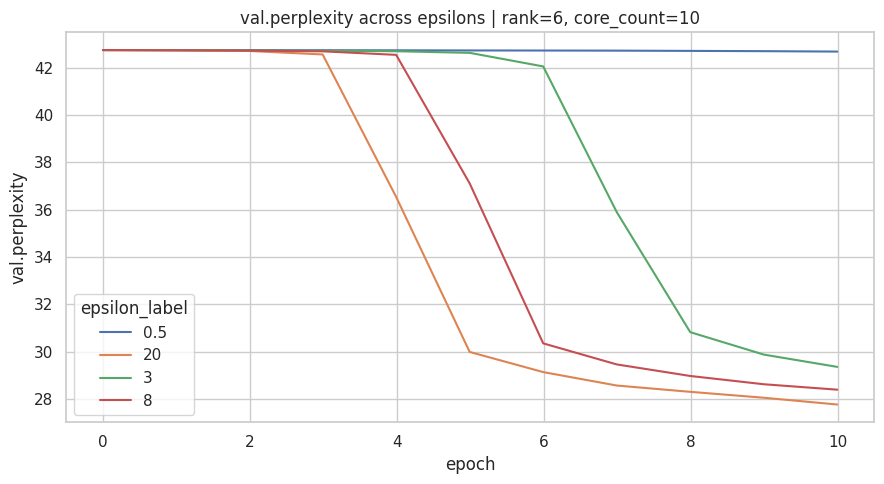

In [25]:
def plot_setting_across_epsilons(rank: int, core_count: int, metric: str = 'val.perplexity', x: str = 'epoch'):
    subset = df[(df['rank'] == rank) & (df['core_count'] == core_count)].copy()
    subset = subset.sort_values([x, 'step'])
    if subset.empty:
        print(f'No rows found for rank={rank}, core_count={core_count}')
        return
    plt.figure(figsize=(9, 5))
    sns.lineplot(data=subset, x=x, y=metric, hue='epsilon_label', estimator=None, units='run_name')
    plt.title(f'{metric} across epsilons | rank={rank}, core_count={core_count}')
    plt.tight_layout()
    plt.show()


plot_setting_across_epsilons(rank=6, core_count=10, metric='val.perplexity', x='epoch')


In [26]:
pivot_best = run_summary.pivot_table(
    index='core_count',
    columns=['rank', 'epsilon'],
    values='best_val_perplexity',
    aggfunc='min',
)
display(pivot_best)


rank               2                                           6              \
epsilon          0.5        3.0        8.0        20.0       0.5        3.0    
core_count                                                                     
2           31.493182  27.796956  26.559527  25.580505  32.143279  28.408669   
3           29.654999  25.762414  24.912038  24.306039  30.288288  26.987206   
4           28.072764  25.707798  24.761366  24.246807  27.247075  25.267163   
5           28.489219  26.203649  25.341056  24.675529  27.515745  25.444275   
6           28.405916  26.600507  25.988448  25.514624  30.397360  27.254975   
7           28.219154  26.593317  26.160161  25.691291  28.720458  26.951140   
8           29.613576  27.179628  26.707562  26.359274  42.528370  29.752145   
9           29.454012  27.733051  27.335987  27.041242  42.681425  28.408784   
10          29.694174  27.988182  27.548541  27.221846  42.681136  29.351909   
11          29.967720  28.264331  27.779013  27.456100  42.696074  29.053509   
12          31.824649  28.596921  28.114568  27.619485  42.746898  42.746274   
13          30.689486  28.918730  28.568244  28.065694  42.746705  42.746695   
14          31.504916  28.773936  28.303734  28.046523  42.746805  42.746764   
15          31.771943  29.146110  28.865686  28.595107  42.746868  42.746869   
16          38.251428  30.401824  29.347934  28.759756  42.746863  42.746861   
17          41.725617  30.335535  29.588875  29.168958  42.746894  42.746894   
18          42.735973  30.029214  29.652790  29.193833  42.746897  42.746893   
19          42.733904  41.255063  32.439316  30.364923  42.746898  42.746894   

rank                                     10                                   
epsilon          8.0        20.0       0.5        3.0        8.0        20.0  
core_count                                                                    
2           27.557993  26.745906  33.277103  29.075129  28.043896  27.277137  
3           25.843578  25.043130  30.387209  27.726234  26.840527  26.068030  
4           24.637430  24.137142  27.528111  25.598867  25.022119  24.516338  
5           24.415062  23.926765  27.295825  25.783612  25.263643  24.691027  
6           26.494253  25.887609  29.603875  27.128947  26.469217  26.030811  
7           26.525704  26.113360  30.145040  26.796941  26.375823  25.939881  
8           28.373769  27.497093  42.710968  31.311273  28.723516  27.987686  
9           27.680080  27.245106  42.727068  42.519906  30.906602  28.959315  
10          28.388855  27.761004  42.727998  39.820584  28.797953  27.960797  
11          28.439079  28.249937  42.731064  31.658426  28.838382  28.008405  
12          42.745395  42.742621  42.745863  42.745449  42.745162  42.744765  
13          42.746686  42.746671  42.746875  42.746873  42.746872  42.746859  
14          42.746723  42.746678  42.746860  42.746850  42.746855  42.746850  
15          42.746862  42.746865  42.746890  42.746889  42.746884  42.746887  
16          42.746854  42.746858  42.746896  42.746897  42.746898  42.746895  
17          42.746895  42.746894  42.746897  42.746897  42.746895  42.746897  
18          42.746898  42.746898  42.746895  42.746896  42.746898  42.746899  
19          42.746896  42.746897  42.746897  42.746897  42.746897  42.746896

## Core Count vs Best Validation Perplexity

These plots put the main question front and center:
- x-axis: core count
- left y-axis: best validation perplexity (lower is better)
- right y-axis: parameter count in K
- one perplexity line per epsilon value

This lets us check whether changing the TT core count matters in private training, while also keeping the parameter-count trend visible on the same plot.


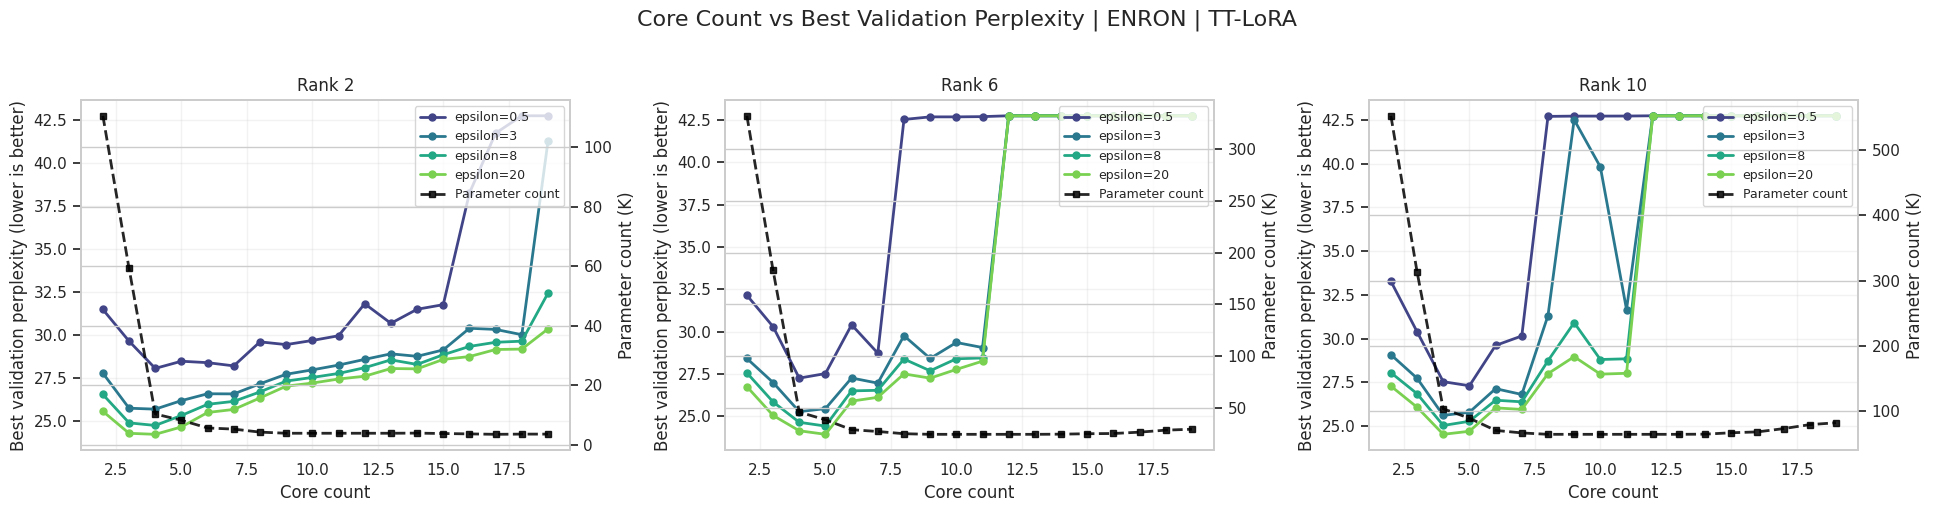

In [27]:
def plot_core_count_vs_best_val_perplexity(run_summary_df: pd.DataFrame, dataset: str = 'enron'):
    subset = run_summary_df[run_summary_df['dataset'].astype(str).str.lower() == dataset.lower()].copy()
    if subset.empty:
        print(f'No runs found for dataset={dataset}')
        return

    ranks = sorted(subset['rank'].dropna().unique())
    if not ranks:
        print('No rank values found in run summary.')
        return

    ncols = min(3, max(1, len(ranks)))
    nrows = math.ceil(len(ranks) / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6.5 * ncols, 5.0 * nrows), squeeze=False)

    epsilon_palette = {
        epsilon: color
        for epsilon, color in zip(sorted(subset['epsilon'].dropna().unique()), sns.color_palette('viridis', n_colors=max(1, subset['epsilon'].nunique())))
    }

    for idx, rank in enumerate(ranks):
        ax = axes[idx // ncols][idx % ncols]
        rank_df = subset[subset['rank'] == rank].copy()
        rank_df = rank_df.sort_values(['epsilon', 'core_count'])

        param_curve = (
            rank_df.groupby('core_count', as_index=False)['num_params']
            .median()
            .sort_values('core_count')
        )

        ax2 = ax.twinx()
        ax2.plot(
            param_curve['core_count'],
            param_curve['num_params'] / 1000.0,
            color='black',
            linestyle='--',
            marker='s',
            linewidth=2,
            markersize=5,
            label='Parameter count',
            alpha=0.85,
        )

        for epsilon in sorted(rank_df['epsilon'].dropna().unique()):
            eps_df = rank_df[rank_df['epsilon'] == epsilon].sort_values('core_count')
            ax.plot(
                eps_df['core_count'],
                eps_df['best_val_perplexity'],
                marker='o',
                linewidth=2,
                markersize=5,
                color=epsilon_palette[epsilon],
                label=f'epsilon={epsilon:g}',
            )

        ax.set_title(f'Rank {int(rank)}')
        ax.set_xlabel('Core count')
        ax.set_ylabel('Best validation perplexity (lower is better)')
        ax2.set_ylabel('Parameter count (K)')
        ax.grid(alpha=0.25)

        handles1, labels1 = ax.get_legend_handles_labels()
        handles2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(handles1 + handles2, labels1 + labels2, loc='upper right', fontsize=9, frameon=True)

    for idx in range(len(ranks), nrows * ncols):
        axes[idx // ncols][idx % ncols].axis('off')

    fig.suptitle(f'Core Count vs Best Validation Perplexity | {dataset.upper()} | TT-LoRA', y=1.02, fontsize=16)
    fig.tight_layout()
    return fig


fig = plot_core_count_vs_best_val_perplexity(run_summary, dataset='enron')
plt.show()


## Combined Rank Comparison

This view overlays all three ranks in one figure.

- color: epsilon
- line style / marker: rank
- left y-axis: best validation perplexity
- right y-axis: parameter count in K

This is useful for checking whether the core-count trend changes with rank, and whether higher-rank runs consistently win at the same epsilon.


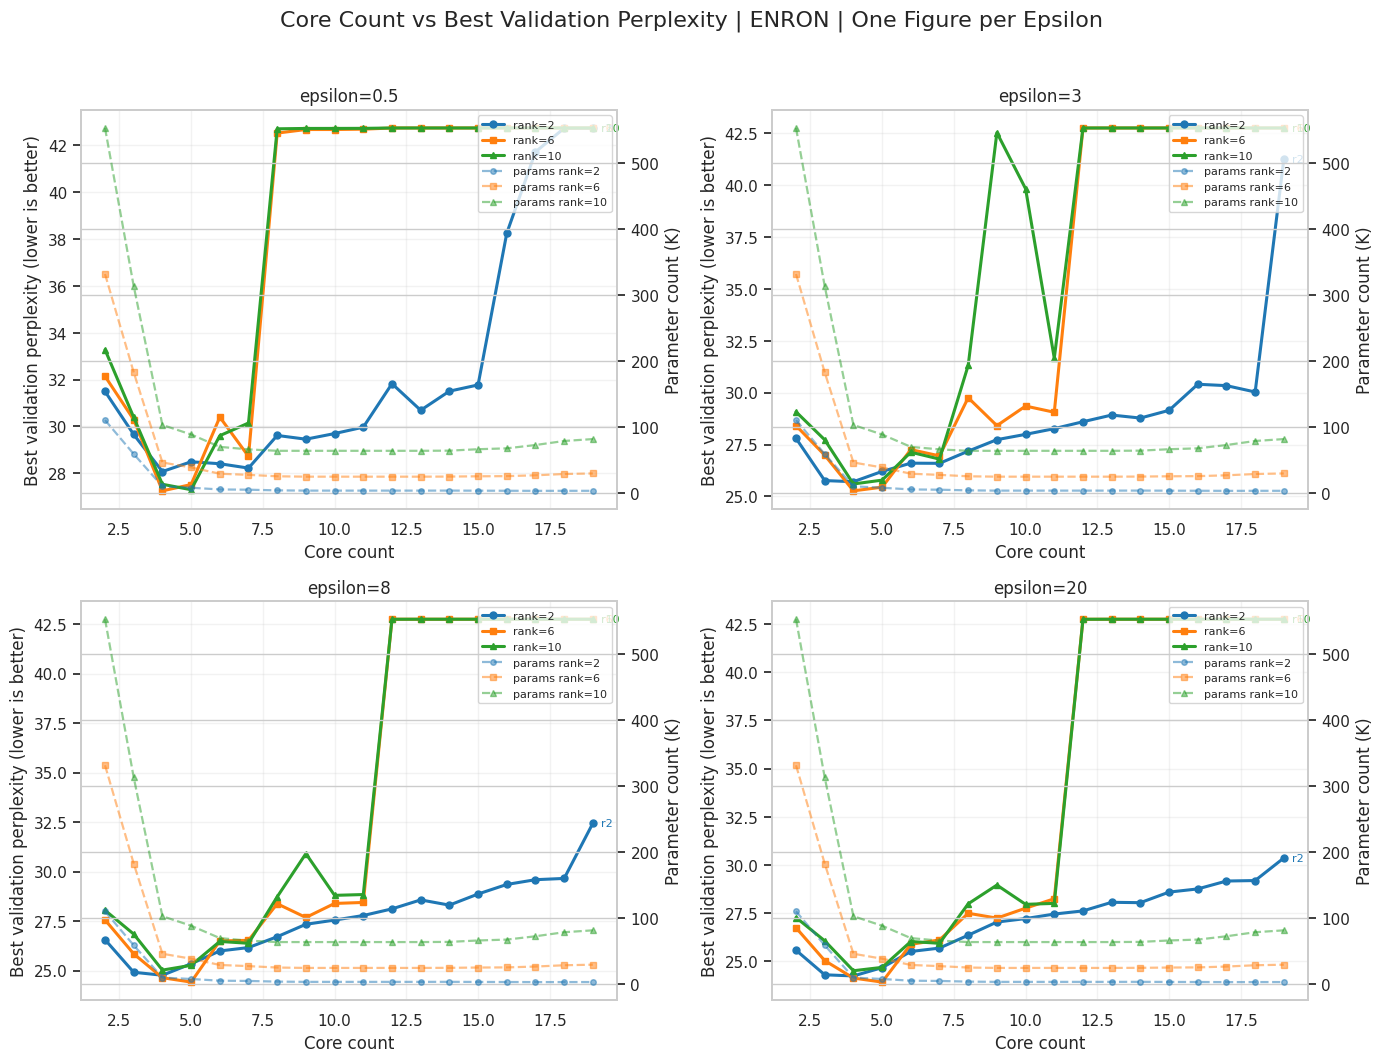

In [28]:
def plot_core_count_vs_best_val_perplexity_by_epsilon(run_summary_df: pd.DataFrame, dataset: str = 'enron'):
    subset = run_summary_df[run_summary_df['dataset'].astype(str).str.lower() == dataset.lower()].copy()
    if subset.empty:
        print(f'No runs found for dataset={dataset}')
        return

    subset = subset.sort_values(['epsilon', 'rank', 'core_count'])
    ranks = sorted(subset['rank'].dropna().unique())
    epsilons = sorted(subset['epsilon'].dropna().unique())
    if not ranks or not epsilons:
        print('Need both rank and epsilon values for the per-epsilon comparison plot.')
        return

    rank_markers = {
        rank: marker for rank, marker in zip(ranks, ['o', 's', '^', 'D'])
    }
    rank_palette = {
        rank: color for rank, color in zip(ranks, sns.color_palette('tab10', n_colors=len(ranks)))
    }

    ncols = min(2, max(1, len(epsilons)))
    nrows = math.ceil(len(epsilons) / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(7 * ncols, 5.2 * nrows), squeeze=False)

    for idx, epsilon in enumerate(epsilons):
        ax = axes[idx // ncols][idx % ncols]
        ax2 = ax.twinx()
        eps_df = subset[subset['epsilon'] == epsilon].copy()

        for rank in ranks:
            rank_df = eps_df[eps_df['rank'] == rank].sort_values('core_count')
            if rank_df.empty:
                continue

            ax.plot(
                rank_df['core_count'],
                rank_df['best_val_perplexity'],
                color=rank_palette[rank],
                linestyle='-',
                marker=rank_markers[rank],
                linewidth=2.2,
                markersize=5,
                label=f'rank={int(rank)}',
            )

            ax2.plot(
                rank_df['core_count'],
                rank_df['num_params'] / 1000.0,
                color=rank_palette[rank],
                linestyle='--',
                marker=rank_markers[rank],
                linewidth=1.6,
                markersize=4,
                alpha=0.5,
                label=f'params rank={int(rank)}',
            )

            last_row = rank_df.iloc[-1]
            ax.annotate(
                f'r{int(rank)}',
                xy=(last_row['core_count'], last_row['best_val_perplexity']),
                xytext=(6, 0),
                textcoords='offset points',
                color=rank_palette[rank],
                fontsize=8,
                va='center',
            )

        ax.set_title(f'epsilon={epsilon:g}')
        ax.set_xlabel('Core count')
        ax.set_ylabel('Best validation perplexity (lower is better)')
        ax2.set_ylabel('Parameter count (K)')
        ax.grid(alpha=0.25)

        handles1, labels1 = ax.get_legend_handles_labels()
        handles2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(handles1 + handles2, labels1 + labels2, loc='upper right', fontsize=8, frameon=True)

    for idx in range(len(epsilons), nrows * ncols):
        axes[idx // ncols][idx % ncols].axis('off')

    fig.suptitle(f'Core Count vs Best Validation Perplexity | {dataset.upper()} | One Figure per Epsilon', y=1.02, fontsize=16)
    fig.tight_layout()
    return fig


fig = plot_core_count_vs_best_val_perplexity_by_epsilon(run_summary, dataset='enron')
plt.show()


## Heatmaps

These heatmaps summarize how utility changes across the `core_count x epsilon` grid.

We plot one heatmap per rank for:
- `best_val_perplexity`
- `final_val_perplexity`
- `final - best` gap

The gap is especially useful for spotting unstable settings.


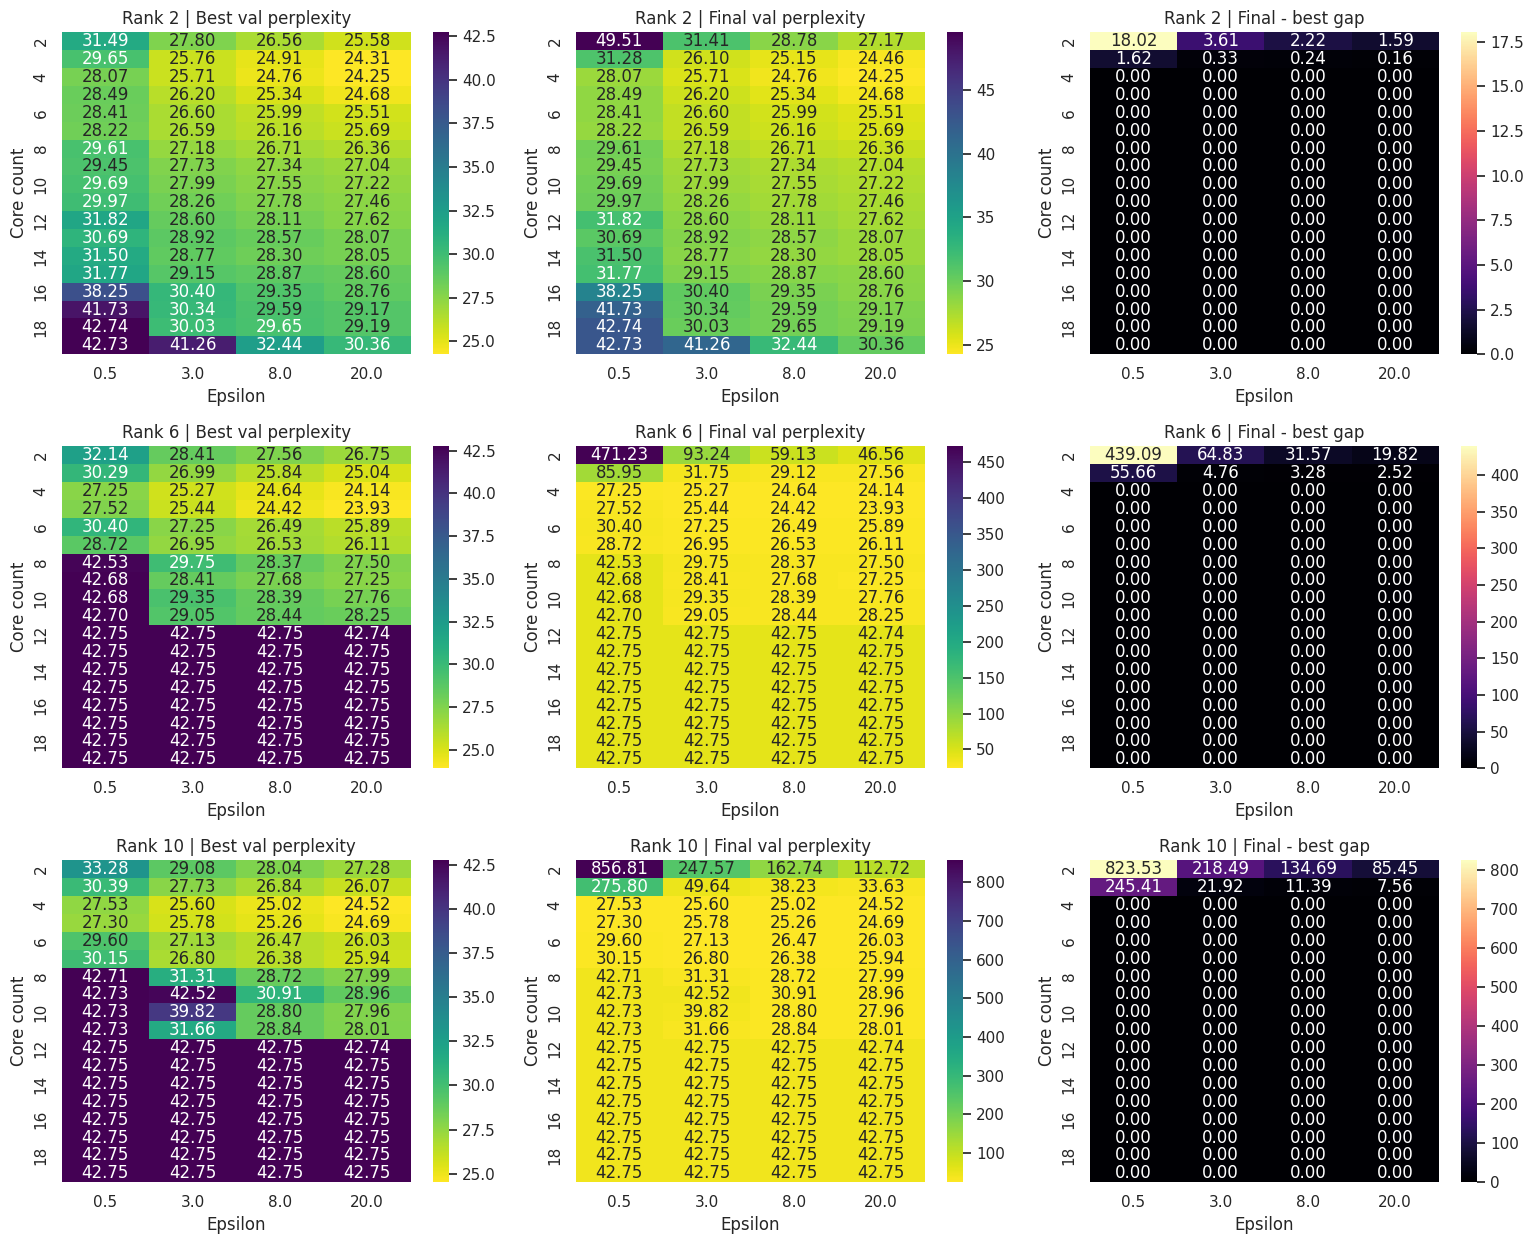

In [29]:
def plot_rank_heatmaps(run_summary_df: pd.DataFrame, dataset: str = 'enron'):
    subset = run_summary_df[run_summary_df['dataset'].astype(str).str.lower() == dataset.lower()].copy()
    if subset.empty:
        print(f'No runs found for dataset={dataset}')
        return

    subset['final_minus_best_gap'] = subset['final_val_perplexity'] - subset['best_val_perplexity']
    ranks = sorted(subset['rank'].dropna().unique())
    metrics = [
        ('best_val_perplexity', 'Best val perplexity'),
        ('final_val_perplexity', 'Final val perplexity'),
        ('final_minus_best_gap', 'Final - best gap'),
    ]

    fig, axes = plt.subplots(len(ranks), len(metrics), figsize=(5.2 * len(metrics), 4.2 * len(ranks)), squeeze=False)

    for row_idx, rank in enumerate(ranks):
        rank_df = subset[subset['rank'] == rank]
        for col_idx, (metric, title) in enumerate(metrics):
            ax = axes[row_idx][col_idx]
            pivot = rank_df.pivot_table(index='core_count', columns='epsilon', values=metric, aggfunc='min')
            sns.heatmap(pivot.sort_index(), annot=True, fmt='.2f', cmap='viridis_r' if metric != 'final_minus_best_gap' else 'magma', ax=ax)
            ax.set_title(f'Rank {int(rank)} | {title}')
            ax.set_xlabel('Epsilon')
            ax.set_ylabel('Core count')

    fig.tight_layout()
    return fig


fig = plot_rank_heatmaps(run_summary, dataset='enron')
plt.show()


## Why Does Performance Drop After 4-5 Cores?

These diagnostics focus directly on the hypothesis that larger core counts may become harder to optimize under DP noise.

We look at:
- core count vs best validation perplexity
- core count vs `final - best` gap
- core count vs best epoch
- core count vs SNR / clipping

If performance degrades after 4-5 cores, these plots help tell whether the reason is instability, later drift, lower SNR, or stronger clipping.


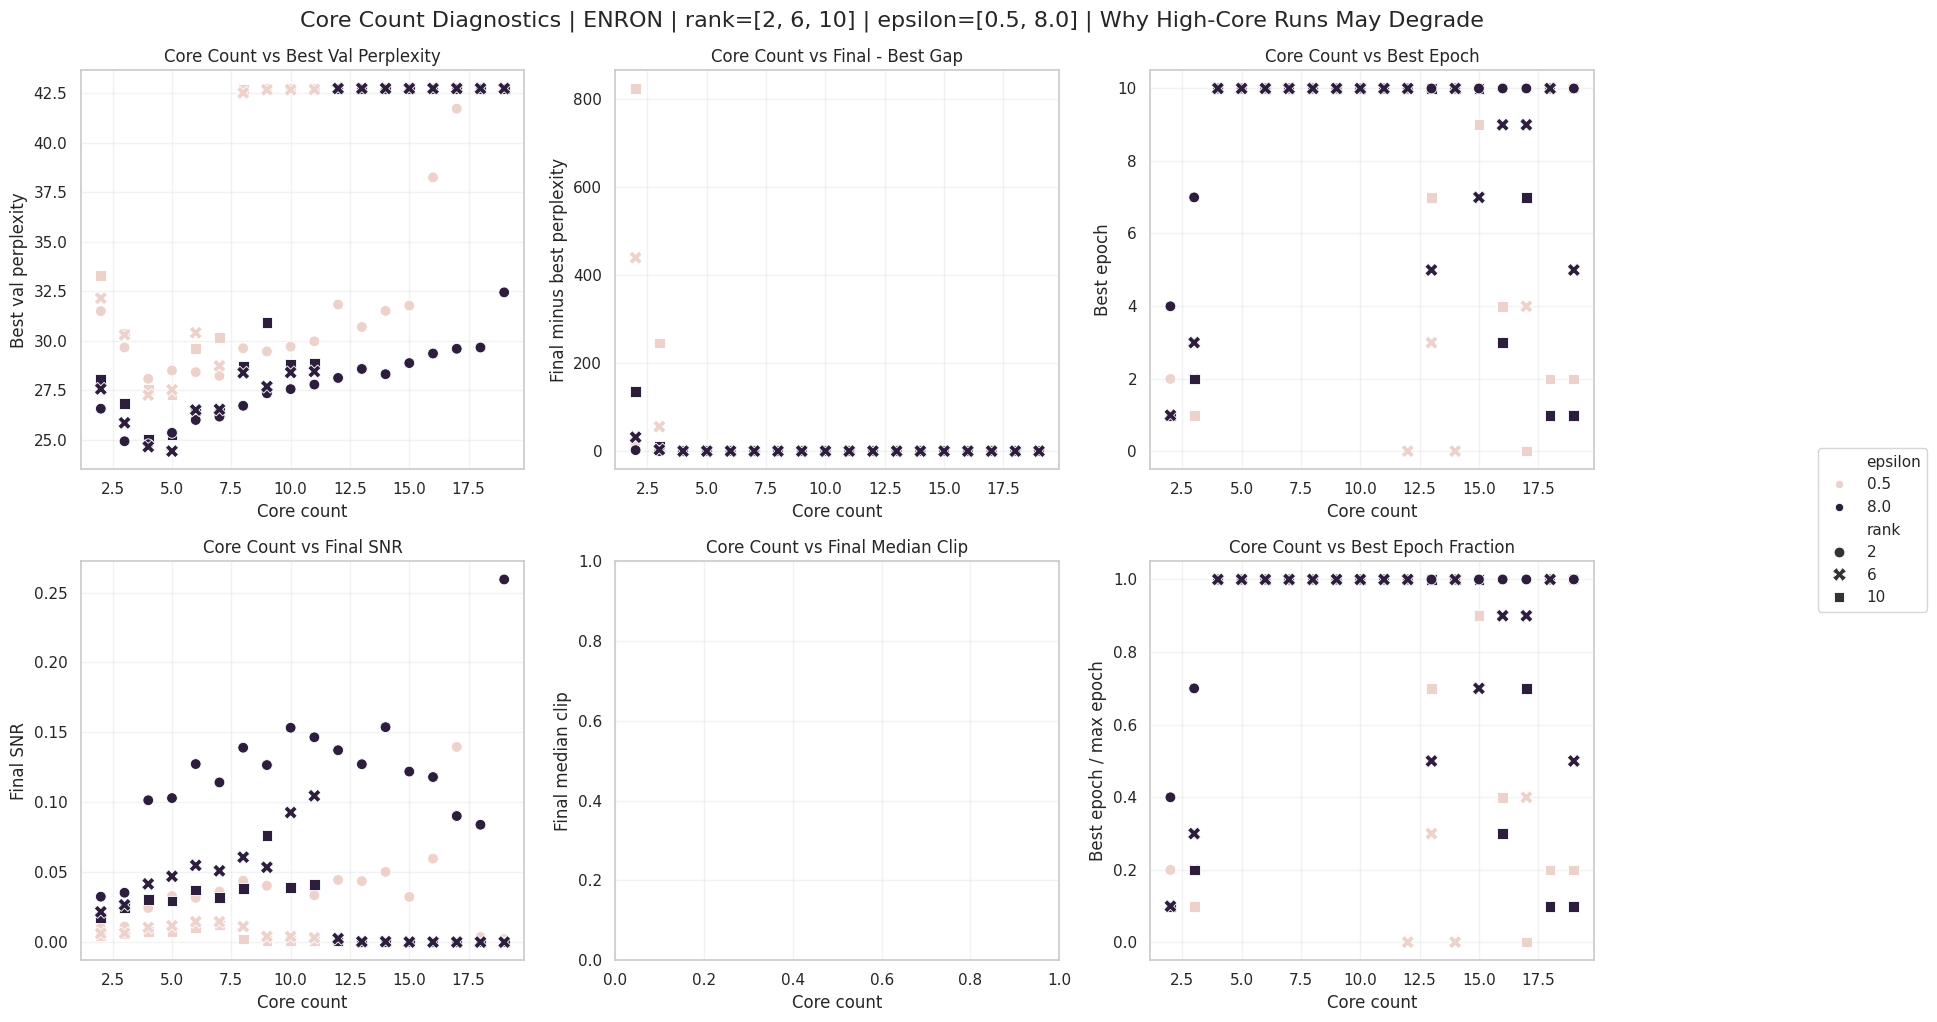

In [30]:
import numpy as np
def _normalize_selector(value):
    if value is None:
        return None
    if isinstance(value, (list, tuple, set, np.ndarray, pd.Series)):
        return list(value)
    return [value]


def plot_core_count_diagnostics(
    run_summary_df: pd.DataFrame,
    dataset: str = 'enron',
    rank_filter=None,
    epsilon_filter=None,
):
    subset = run_summary_df[run_summary_df['dataset'].astype(str).str.lower() == dataset.lower()].copy()
    rank_values = _normalize_selector(rank_filter)
    epsilon_values = _normalize_selector(epsilon_filter)
    if rank_values is not None:
        subset = subset[subset['rank'].isin(rank_values)].copy()
    if epsilon_values is not None:
        subset = subset[subset['epsilon'].isin(epsilon_values)].copy()
    if subset.empty:
        print(
            f'No runs found for dataset={dataset}, rank={rank_filter}, epsilon={epsilon_filter}'
        )
        return

    subset['final_minus_best_gap'] = subset['final_val_perplexity'] - subset['best_val_perplexity']
    subset['best_epoch_fraction'] = subset['best_val_epoch'] / subset['max_epoch']

    fig, axes = plt.subplots(2, 3, figsize=(18, 10), squeeze=False)
    use_grouping = (
        rank_values is None
        or epsilon_values is None
        or len(rank_values) != 1
        or len(epsilon_values) != 1
    )
    if use_grouping:
        common_kwargs = dict(hue='epsilon', style='rank', size='rank', sizes=(60, 120))
    else:
        common_kwargs = dict(color='#1f77b4', s=90)

    sns.scatterplot(data=subset, x='core_count', y='best_val_perplexity', ax=axes[0][0], **common_kwargs)
    axes[0][0].set_title('Core Count vs Best Val Perplexity')
    axes[0][0].set_xlabel('Core count')
    axes[0][0].set_ylabel('Best val perplexity')

    sns.scatterplot(data=subset, x='core_count', y='final_minus_best_gap', ax=axes[0][1], **common_kwargs)
    axes[0][1].set_title('Core Count vs Final - Best Gap')
    axes[0][1].set_xlabel('Core count')
    axes[0][1].set_ylabel('Final minus best perplexity')

    sns.scatterplot(data=subset, x='core_count', y='best_val_epoch', ax=axes[0][2], **common_kwargs)
    axes[0][2].set_title('Core Count vs Best Epoch')
    axes[0][2].set_xlabel('Core count')
    axes[0][2].set_ylabel('Best epoch')

    sns.scatterplot(data=subset, x='core_count', y='final_snr', ax=axes[1][0], **common_kwargs)
    axes[1][0].set_title('Core Count vs Final SNR')
    axes[1][0].set_xlabel('Core count')
    axes[1][0].set_ylabel('Final SNR')

    sns.scatterplot(data=subset, x='core_count', y='final_med_clip', ax=axes[1][1], **common_kwargs)
    axes[1][1].set_title('Core Count vs Final Median Clip')
    axes[1][1].set_xlabel('Core count')
    axes[1][1].set_ylabel('Final median clip')

    sns.scatterplot(data=subset, x='core_count', y='best_epoch_fraction', ax=axes[1][2], **common_kwargs)
    axes[1][2].set_title('Core Count vs Best Epoch Fraction')
    axes[1][2].set_xlabel('Core count')
    axes[1][2].set_ylabel('Best epoch / max epoch')

    for ax in axes.ravel():
        ax.grid(alpha=0.25)

    title_parts = [dataset.upper()]
    if rank_values is not None:
        title_parts.append(f'rank={rank_values}')
    if epsilon_values is not None:
        title_parts.append(f'epsilon={epsilon_values}')

    if use_grouping:
        handles, labels = axes[0][0].get_legend_handles_labels()
        for ax in axes.ravel():
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()
        fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=True)
        fig.tight_layout(rect=[0, 0, 0.9, 1.0])
    else:
        fig.tight_layout()

    fig.suptitle(
        'Core Count Diagnostics | ' + ' | '.join(title_parts) + ' | Why High-Core Runs May Degrade',
        y=1.02,
        fontsize=16,
    )
    return fig


selected_ranks = [2,6,10]
selected_epsilons = [0.5,8.0]
fig = plot_core_count_diagnostics(
    run_summary,
    dataset='enron',
    rank_filter=selected_ranks,
    epsilon_filter=selected_epsilons,
)
plt.show()


In [31]:
core_diag_table = run_summary.copy()
core_diag_table['final_minus_best_gap'] = core_diag_table['final_val_perplexity'] - core_diag_table['best_val_perplexity']
core_diag_table['best_epoch_fraction'] = core_diag_table['best_val_epoch'] / core_diag_table['max_epoch']

core_diag_summary = (
    core_diag_table.groupby(['rank', 'epsilon', 'core_count'])
    .agg(
        best_val_perplexity=('best_val_perplexity', 'min'),
        final_val_perplexity=('final_val_perplexity', 'min'),
        final_minus_best_gap=('final_minus_best_gap', 'mean'),
        best_val_epoch=('best_val_epoch', 'mean'),
        best_epoch_fraction=('best_epoch_fraction', 'mean'),
        final_snr=('final_snr', 'mean'),
        final_med_clip=('final_med_clip', 'mean'),
        num_params=('num_params', 'mean'),
    )
    .reset_index()
    .sort_values(['rank', 'epsilon', 'core_count'])
)

filtered_core_diag_summary = core_diag_summary.copy()
if selected_ranks is not None:
    filtered_core_diag_summary = filtered_core_diag_summary[
        filtered_core_diag_summary['rank'].isin(selected_ranks)
    ].copy()
if selected_epsilons is not None:
    filtered_core_diag_summary = filtered_core_diag_summary[
        filtered_core_diag_summary['epsilon'].isin(selected_epsilons)
    ].copy()

display(filtered_core_diag_summary)


,rank,epsilon,core_count,best_val_perplexity,final_val_perplexity,final_minus_best_gap,best_val_epoch,best_epoch_fraction,final_snr,final_med_clip,num_params
0,2,0.5,2,31.493182,49.514034,18.020852,1.988048,0.199043,1.029150e-02,NaN,110592.0
1,2,0.5,3,29.654999,31.279025,1.624026,2.988048,0.299162,1.114740e-02,NaN,59232.0
2,2,0.5,4,28.072764,28.072764,0.000000,9.988048,1.000000,2.440395e-02,NaN,10272.0
3,2,0.5,5,28.489219,28.489219,0.000000,9.988048,1.000000,3.298785e-02,NaN,8160.0
4,2,0.5,6,28.405916,28.405916,0.000000,9.988048,1.000000,3.167539e-02,NaN,5568.0
...,...,...,...,...,...,...,...,...,...,...,...
193,10,8.0,15,42.746884,42.746884,0.000000,9.988048,1.000000,8.759801e-06,NaN,66480.0
194,10,8.0,16,42.746898,42.746904,0.000007,2.988048,0.299162,9.483237e-06,NaN,67800.0
195,10,8.0,17,42.746895,42.746899,0.000004,6.988048,0.699641,1.483180e-06,NaN,72840.0
196,10,8.0,18,42.746898,42.746898,0.000000,0.988048,0.098923,2.589982e-07,NaN,78960.0


## SNR vs Parameter Count and Core Count

These plots help check whether private training quality is being limited more by parameter budget or by the TT core structure itself.


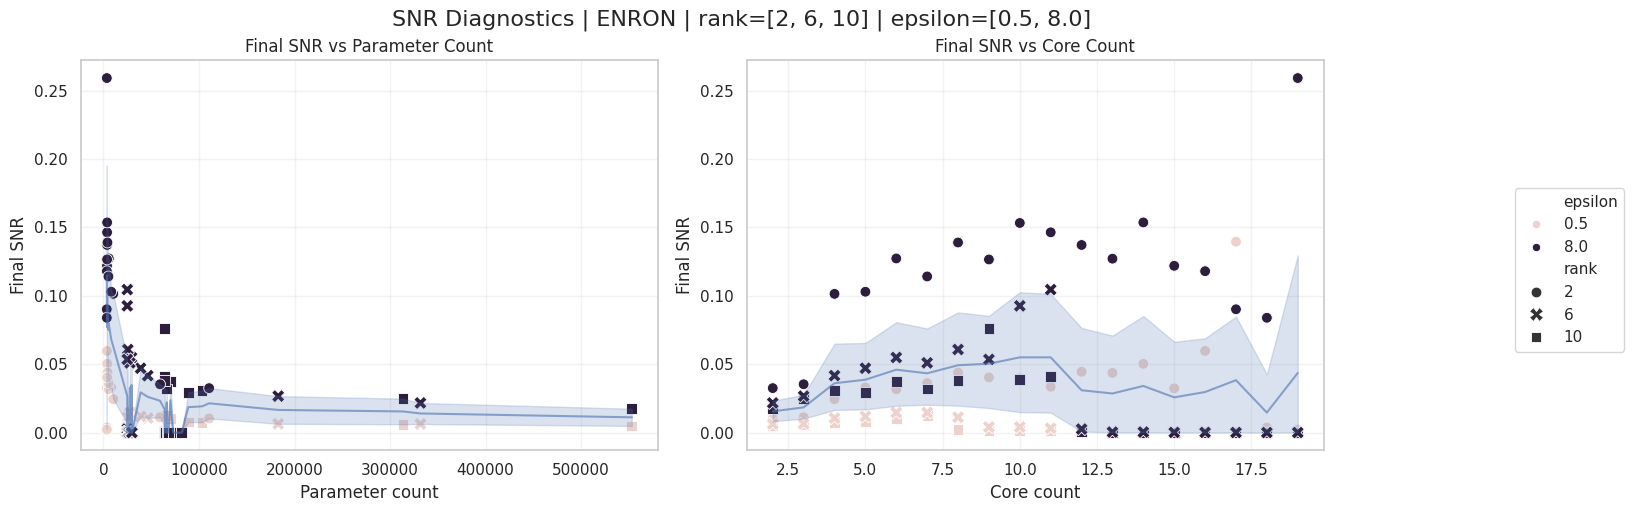

In [32]:
def plot_snr_relationships(
    run_summary_df: pd.DataFrame,
    dataset: str = 'enron',
    rank_filter=None,
    epsilon_filter=None,
):
    subset = run_summary_df[run_summary_df['dataset'].astype(str).str.lower() == dataset.lower()].copy()
    rank_values = _normalize_selector(rank_filter)
    epsilon_values = _normalize_selector(epsilon_filter)
    if rank_values is not None:
        subset = subset[subset['rank'].isin(rank_values)].copy()
    if epsilon_values is not None:
        subset = subset[subset['epsilon'].isin(epsilon_values)].copy()

    subset = subset.dropna(subset=['final_snr', 'num_params', 'core_count'])
    if subset.empty:
        print(
            f'No SNR rows found for dataset={dataset}, rank={rank_filter}, epsilon={epsilon_filter}'
        )
        return

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), squeeze=False)
    use_grouping = (
        rank_values is None
        or epsilon_values is None
        or len(rank_values) != 1
        or len(epsilon_values) != 1
    )
    if use_grouping:
        common_kwargs = dict(hue='epsilon', style='rank', size='rank', sizes=(60, 120))
    else:
        common_kwargs = dict(color='#2a9d8f', s=90)

    sns.scatterplot(data=subset, x='num_params', y='final_snr', ax=axes[0][0], **common_kwargs)
    sns.lineplot(
        data=subset.sort_values('num_params'),
        x='num_params',
        y='final_snr',
        ax=axes[0][0],
        color='#2a9d8f' if not use_grouping else None,
        alpha=0.6,
        legend=False,
    )
    axes[0][0].set_title('Final SNR vs Parameter Count')
    axes[0][0].set_xlabel('Parameter count')
    axes[0][0].set_ylabel('Final SNR')
    axes[0][0].ticklabel_format(axis='x', style='plain')

    sns.scatterplot(data=subset, x='core_count', y='final_snr', ax=axes[0][1], **common_kwargs)
    sns.lineplot(
        data=subset.sort_values('core_count'),
        x='core_count',
        y='final_snr',
        ax=axes[0][1],
        color='#2a9d8f' if not use_grouping else None,
        alpha=0.6,
        legend=False,
    )
    axes[0][1].set_title('Final SNR vs Core Count')
    axes[0][1].set_xlabel('Core count')
    axes[0][1].set_ylabel('Final SNR')

    for ax in axes.ravel():
        ax.grid(alpha=0.25)

    title_parts = [dataset.upper()]
    if rank_values is not None:
        title_parts.append(f'rank={rank_values}')
    if epsilon_values is not None:
        title_parts.append(f'epsilon={epsilon_values}')

    if use_grouping:
        handles, labels = axes[0][0].get_legend_handles_labels()
        for ax in axes.ravel():
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()
        fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=True)
        fig.tight_layout(rect=[0, 0, 0.9, 1.0])
    else:
        fig.tight_layout()

    fig.suptitle('SNR Diagnostics | ' + ' | '.join(title_parts), y=1.02, fontsize=16)
    return fig


fig = plot_snr_relationships(
    run_summary,
    dataset='enron',
    rank_filter=selected_ranks,
    epsilon_filter=selected_epsilons,
)
plt.show()


## Train and Validation Loss Grids from Raw Epsilon CSVs

These figures read the original per-epsilon CSV files directly from the `runs` folder and plot `train.eval_losses` and `val.eval_losses` over epochs. Each figure corresponds to one epsilon value, with rows for ranks and columns for core counts.


In [33]:
RAW_RUNS_DIR = Path('/home/pkunwar/characterize_ttlora/phases/2.2.different_dataset_models_rank/runs')
RAW_EPSILON_FILES = [
    'rank2_6_10_0.5eps.csv',
    'rank2_6_10_3.0eps.csv',
    'rank2_6_10_8.0eps.csv',
    'rank2_6_10_20.0eps.csv',
]

grid_selected_epsilons = [0.5, 3.0, 8.0, 20.0]
grid_selected_ranks = [2, 6, 10]
grid_selected_cores = [2, 3, 4, 5, 6, 7, 8, 9, 10]

RAW_RUNS_DIR, RAW_EPSILON_FILES


(PosixPath('/home/pkunwar/characterize_ttlora/phases/2.2.different_dataset_models_rank/runs'),
 ['rank2_6_10_0.5eps.csv',
  'rank2_6_10_3.0eps.csv',
  'rank2_6_10_8.0eps.csv',
  'rank2_6_10_20.0eps.csv'])

In [34]:
def load_raw_private_loss_rows(raw_runs_dir: Path, epsilon_files: list[str]) -> pd.DataFrame:
    frames = []
    for filename in epsilon_files:
        path = raw_runs_dir / filename
        frame = pd.read_csv(path)
        frame['source_file'] = filename
        frames.append(frame)
    raw_df = pd.concat(frames, ignore_index=True)

    for column in ['rank', 'epsilon', 'core_count', 'epoch', 'train.eval_losses', 'val.eval_losses']:
        if column in raw_df.columns:
            raw_df[column] = pd.to_numeric(raw_df[column], errors='coerce')

    return raw_df


raw_loss_df = load_raw_private_loss_rows(RAW_RUNS_DIR, RAW_EPSILON_FILES)
display(raw_loss_df[['source_file', 'rank', 'epsilon', 'core_count', 'epoch', 'train.eval_losses', 'val.eval_losses']].head())


,source_file,rank,epsilon,core_count,epoch,train.eval_losses,val.eval_losses
0,rank2_6_10_0.5eps.csv,10,0.5,10,0.000000,3.873408,3.755304
1,rank2_6_10_0.5eps.csv,10,0.5,10,0.988048,3.873403,3.755301
2,rank2_6_10_0.5eps.csv,10,0.5,10,1.988048,3.873381,3.755284
3,rank2_6_10_0.5eps.csv,10,0.5,10,2.988048,3.873395,3.755297
4,rank2_6_10_0.5eps.csv,10,0.5,10,3.988048,3.873402,3.755305


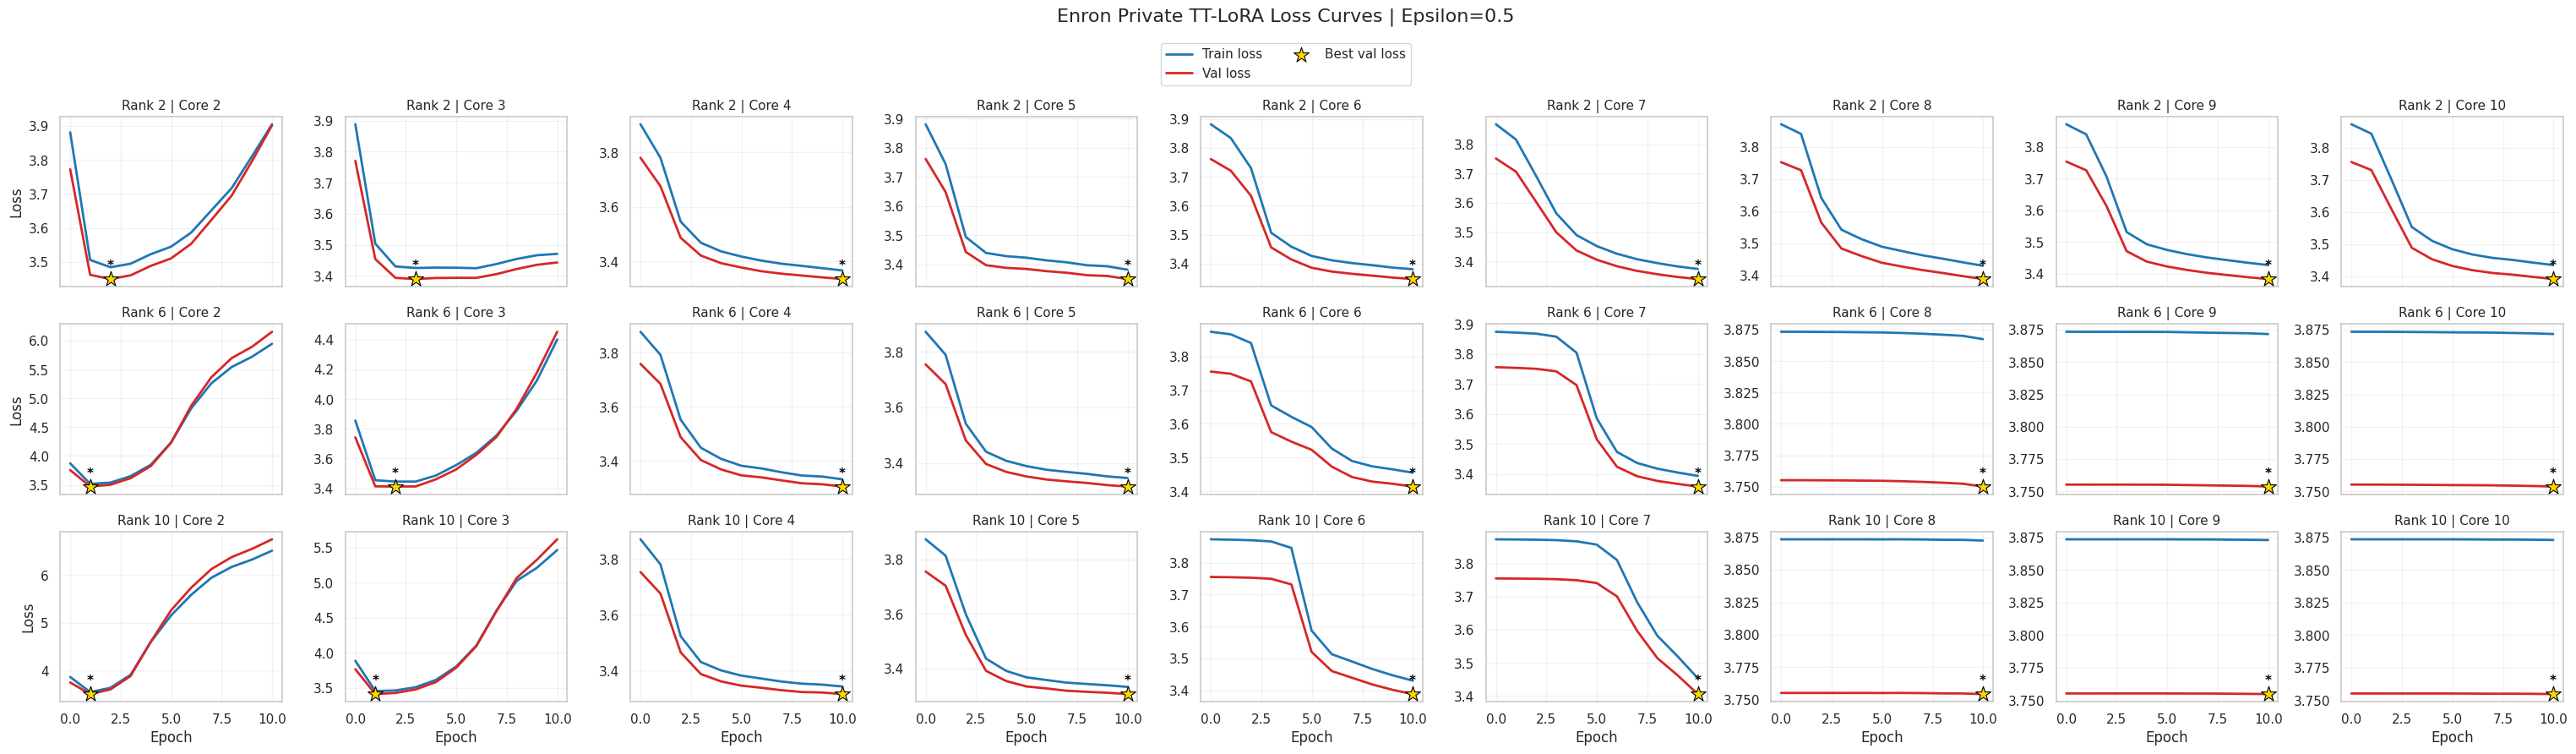

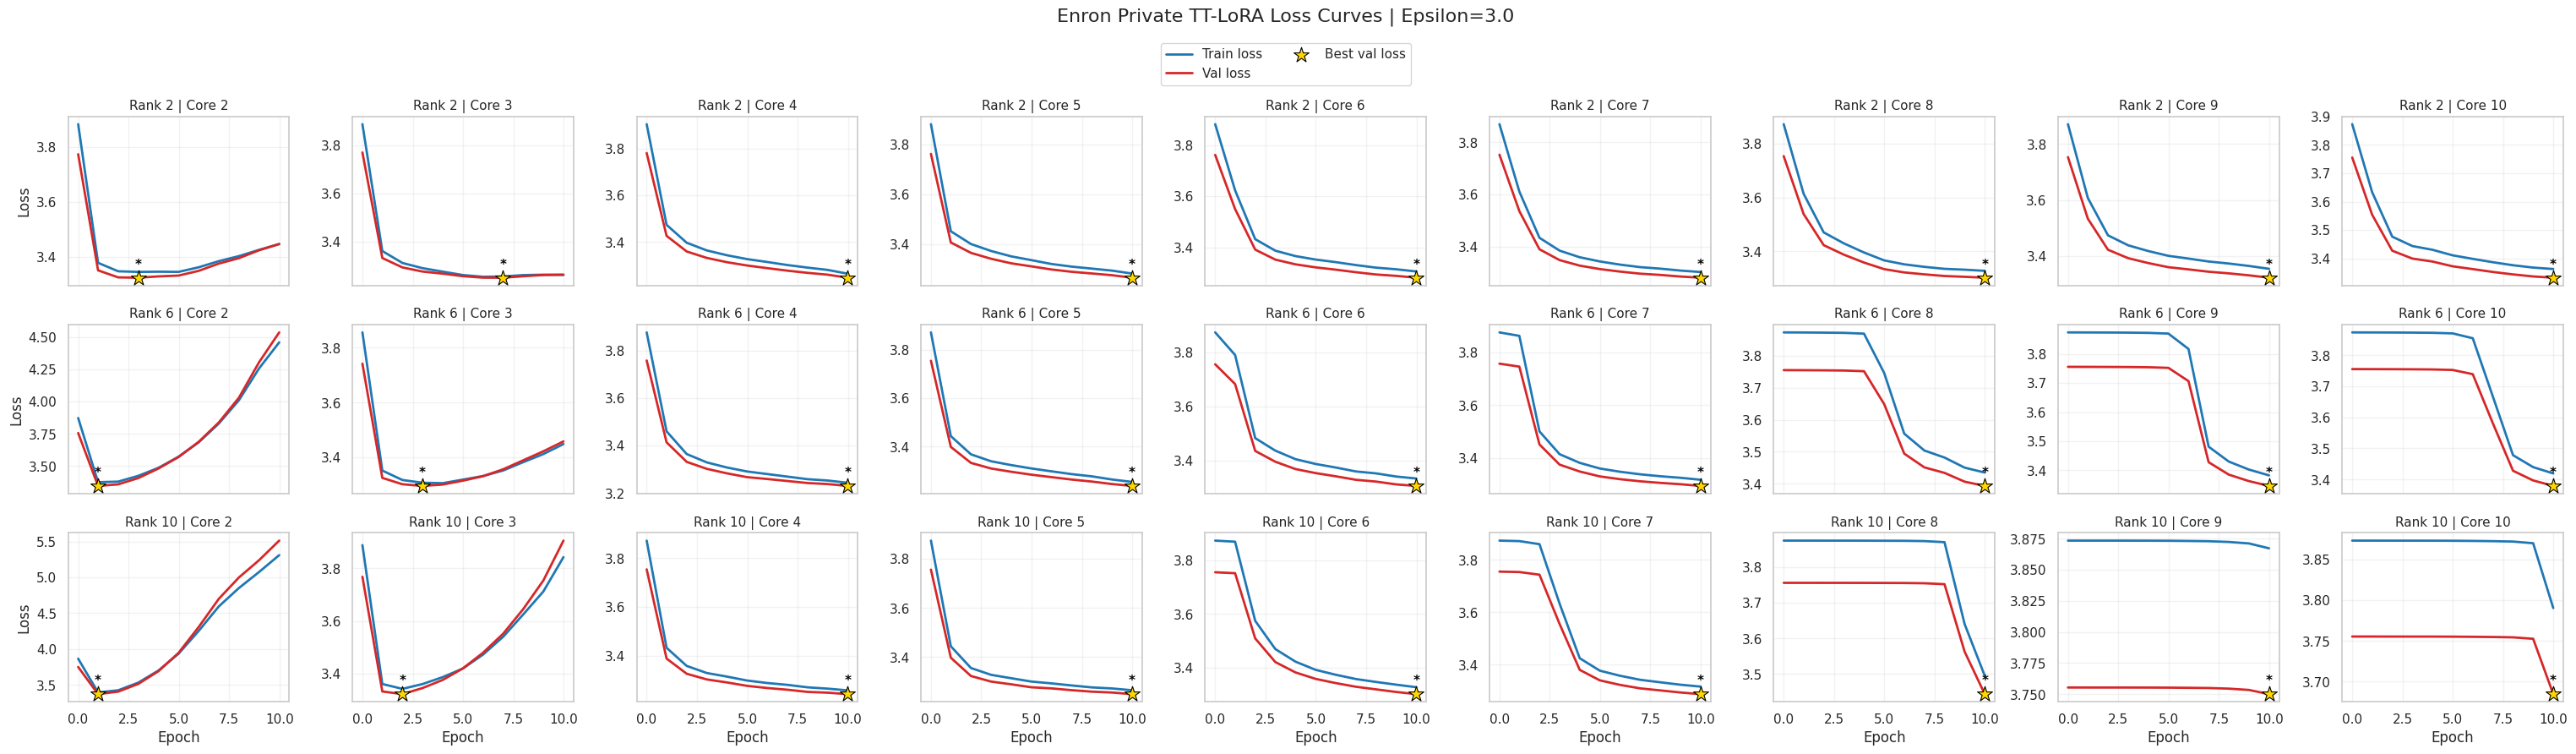

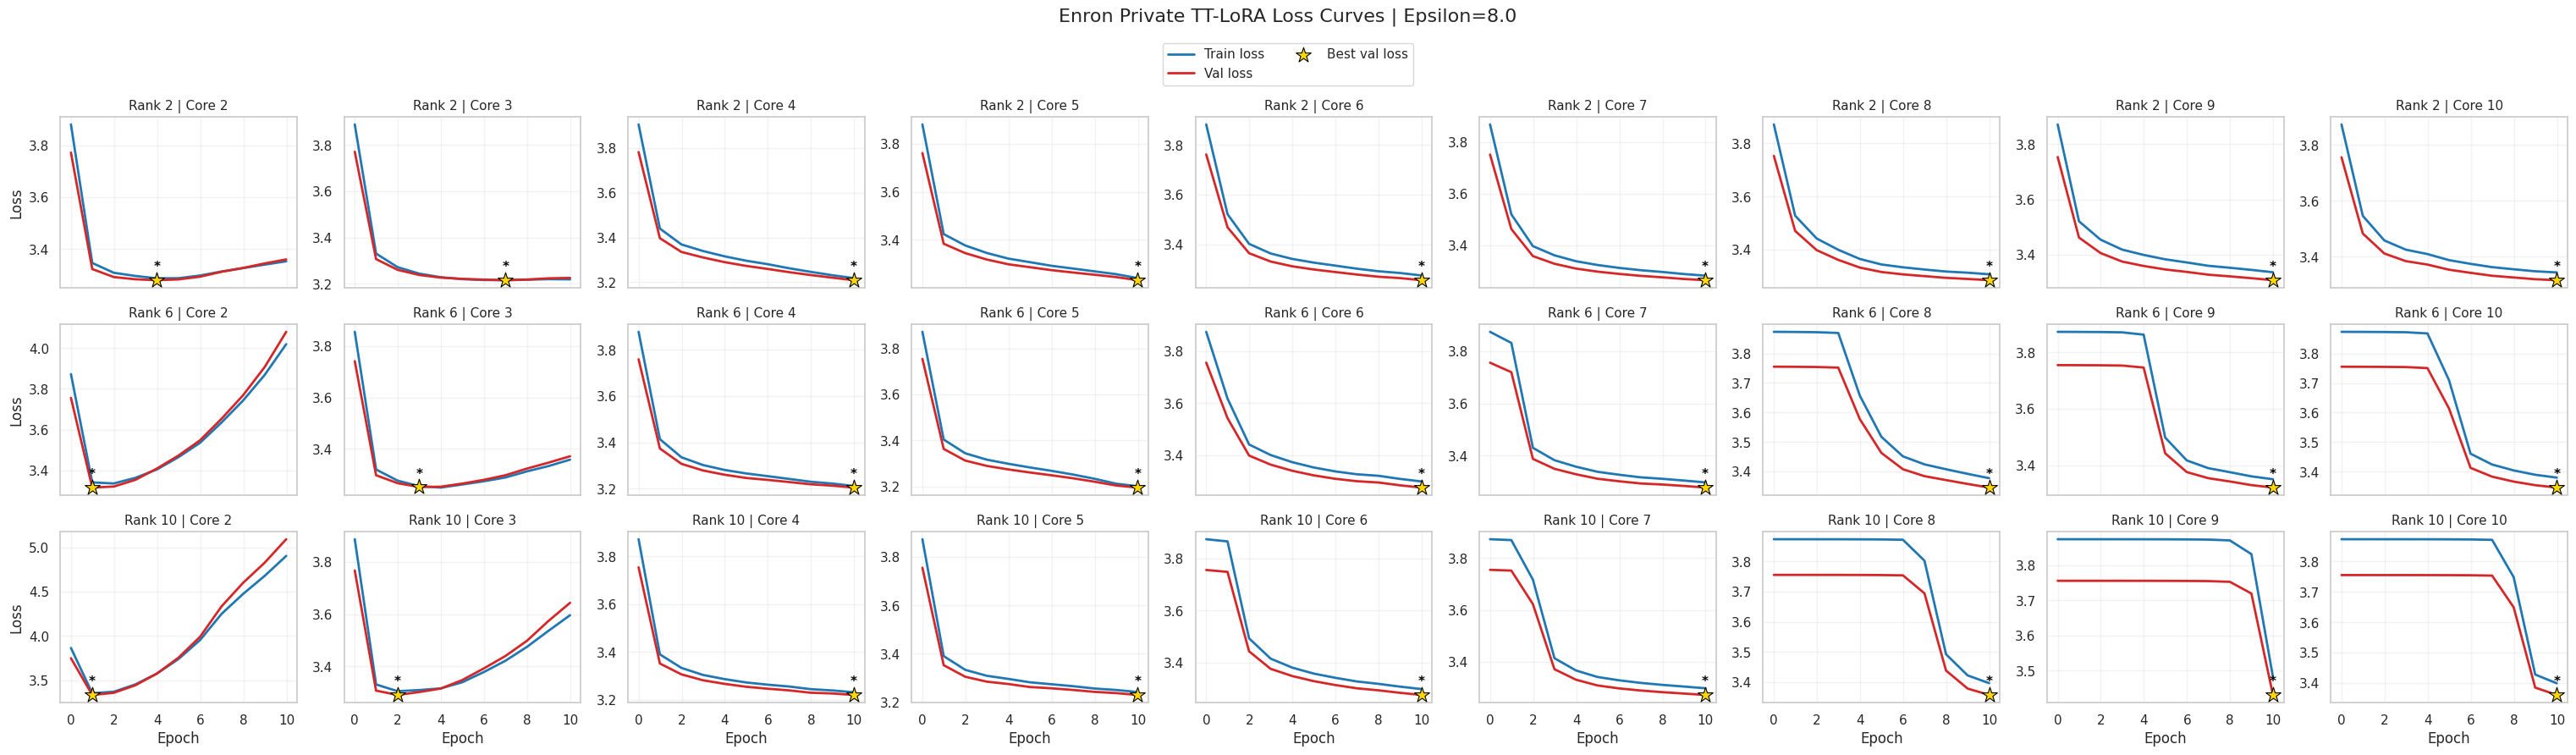

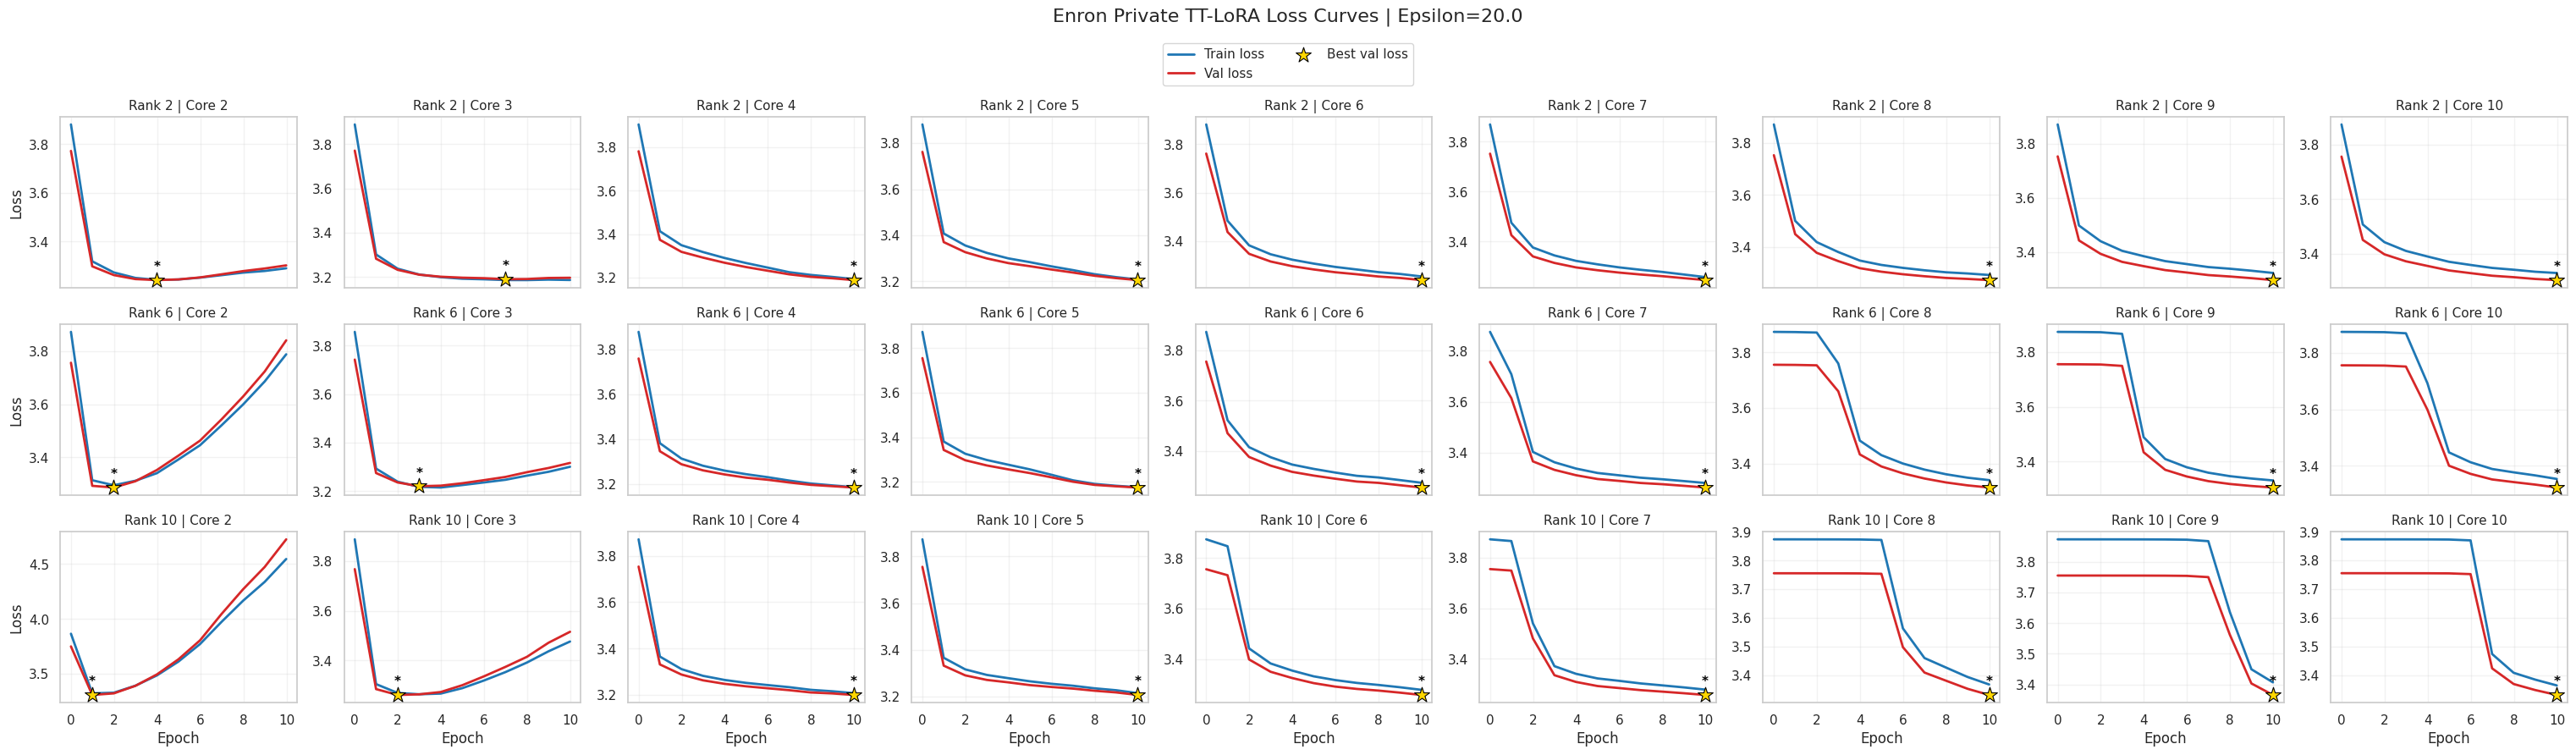

In [35]:
def plot_loss_grids_by_epsilon(
    raw_df: pd.DataFrame,
    selected_epsilons=None,
    selected_ranks=None,
    selected_cores=None,
):
    epsilon_values = _normalize_selector(selected_epsilons)
    rank_values = _normalize_selector(selected_ranks)
    core_values = _normalize_selector(selected_cores)

    subset = raw_df.copy()
    if epsilon_values is not None:
        subset = subset[subset['epsilon'].isin(epsilon_values)].copy()
    if rank_values is not None:
        subset = subset[subset['rank'].isin(rank_values)].copy()
    if core_values is not None:
        subset = subset[subset['core_count'].isin(core_values)].copy()

    subset = subset.dropna(subset=['rank', 'epsilon', 'core_count', 'epoch', 'train.eval_losses', 'val.eval_losses'])
    if subset.empty:
        print('No rows available for the selected epsilon/rank/core filters.')
        return

    epsilon_list = sorted(subset['epsilon'].unique())
    rank_list = sorted(subset['rank'].unique())
    core_list = sorted(subset['core_count'].unique())

    for epsilon in epsilon_list:
        eps_df = subset[subset['epsilon'] == epsilon].copy()
        fig, axes = plt.subplots(
            nrows=len(rank_list),
            ncols=len(core_list),
            figsize=(3.4 * len(core_list), 2.8 * len(rank_list)),
            squeeze=False,
            sharex=True,
            sharey=False,
        )

        for row_idx, rank in enumerate(rank_list):
            for col_idx, core in enumerate(core_list):
                ax = axes[row_idx][col_idx]
                run_df = eps_df[(eps_df['rank'] == rank) & (eps_df['core_count'] == core)].copy()

                if run_df.empty:
                    ax.set_axis_off()
                    continue

                run_df = run_df.sort_values('epoch')
                ax.plot(run_df['epoch'], run_df['train.eval_losses'], color='#1f77b4', linewidth=2, label='Train loss')
                ax.plot(run_df['epoch'], run_df['val.eval_losses'], color='#d62728', linewidth=2, label='Val loss')

                best_idx = run_df['val.eval_losses'].idxmin()
                best_row = run_df.loc[best_idx]
                ax.scatter(
                    best_row['epoch'],
                    best_row['val.eval_losses'],
                    marker='*',
                    s=180,
                    color='gold',
                    edgecolor='black',
                    linewidth=0.8,
                    zorder=5,
                    label='Best val loss' if row_idx == 0 and col_idx == 0 else None,
                )
                ax.annotate(
                    '*',
                    (best_row['epoch'], best_row['val.eval_losses']),
                    textcoords='offset points',
                    xytext=(0, 8),
                    ha='center',
                    color='black',
                    fontsize=11,
                    weight='bold',
                )
                ax.set_title(f'Rank {int(rank)} | Core {int(core)}', fontsize=11)
                ax.grid(alpha=0.25)

                if row_idx == len(rank_list) - 1:
                    ax.set_xlabel('Epoch')
                if col_idx == 0:
                    ax.set_ylabel('Loss')

        handles, labels = axes[0][0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc='upper center', ncol=2, frameon=True, bbox_to_anchor=(0.5, 1.02))

        fig.suptitle(f'Enron Private TT-LoRA Loss Curves | Epsilon={epsilon}', y=1.06, fontsize=16)
        fig.tight_layout()
        plt.show()


plot_loss_grids_by_epsilon(
    raw_loss_df,
    selected_epsilons=grid_selected_epsilons,
    selected_ranks=grid_selected_ranks,
    selected_cores=grid_selected_cores,
)


## Suggested Next Analyses

After this setup, the next high-value analyses are:
1. Compare `best_val_perplexity` vs `core_count` for each `(rank, epsilon)`.
2. Compare `best_val_perplexity` vs `rank` for each `(core_count, epsilon)`.
3. Normalize by parameter count to separate `core count` effects from `parameter budget` effects.
4. Use trend lines of `val.perplexity` and `train.perplexity` to check whether low-epsilon runs plateau earlier or become noisier.
5. Use `snr`, `noise`, and clipping statistics to explain convergence failures.

Once the combined CSV and run summary look correct, we can extend this notebook with those plots next.
